# CALoRa Detection Rate vs SNR — Comparison Plot

Select which result CSV files to overlay on a single graph.

In [198]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

results_dir = os.path.join('.', 'results2')

# List all available CSV files
all_csvs = sorted(glob.glob(os.path.join(results_dir, '*.csv')))
print(f'Available result files in {results_dir}:')
for i, f in enumerate(all_csvs):
    print(f'  [{i}] {os.path.basename(f)}')

Available result files in .\results2:
  [0] calora_clean.csv
  [1] calora_clean_cfo.csv
  [2] calora_results_20260807_162213.csv
  [3] calora_results_20260807_175103.csv
  [4] calora_traincfo_testcfo.csv
  [5] calora_traincfo_testcfosean.csv
  [6] calora_traincfo_testclean.csv


In [199]:
import csv

def format_snr_data(raw_csv_text):
    """
    Takes raw CSV text with 'snr,n,avg_prob,det_rate', 
    and returns a new string formatted as 'SNR,DetRate'.
    """
    # Split the raw text into individual lines
    lines = raw_csv_text.strip().split('\n')
    
    # Initialize the output list with the new header
    formatted_lines = ["SNR,DetRate"]
    
    # Loop through the data, skipping the original header (lines[1:])
    for line in lines[1:]:
        # Skip any empty lines
        if not line.strip():
            continue
            
        parts = line.split(',')
        if len(parts) >= 4:
            snr = parts[0].strip()
            det_rate = parts[3].strip()
            formatted_lines.append(f"{snr},{det_rate}")
            
    # Join everything back into a single multi-line string
    return '\n'.join(formatted_lines)

In [200]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  EDIT HERE: specify the files you want to compare              ║
# ║  Use the exact filenames (without path) from the list above    ║
# ╚══════════════════════════════════════════════════════════════════╝

selected_files = [
    'calora_clean.csv',
    'calora_clean_cfo.csv',
    'calora_results_20260807_162213.csv',
    'calora_traincfo_testclean.csv',
    'calora_traincfo_testcfo.csv'
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    'Calora train clean, test clean (YS)',
    'Calora train clean, test CFO (YS)',
    'calora train clean, test clean (Sean)',
    'calora train cfo (ys), test clean (Ys)',
     'calora train cfo (ys), test cfo (Ys)'
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ calora_clean.csv
✅ calora_clean_cfo.csv
✅ calora_results_20260807_162213.csv
✅ calora_traincfo_testclean.csv
✅ calora_traincfo_testcfo.csv


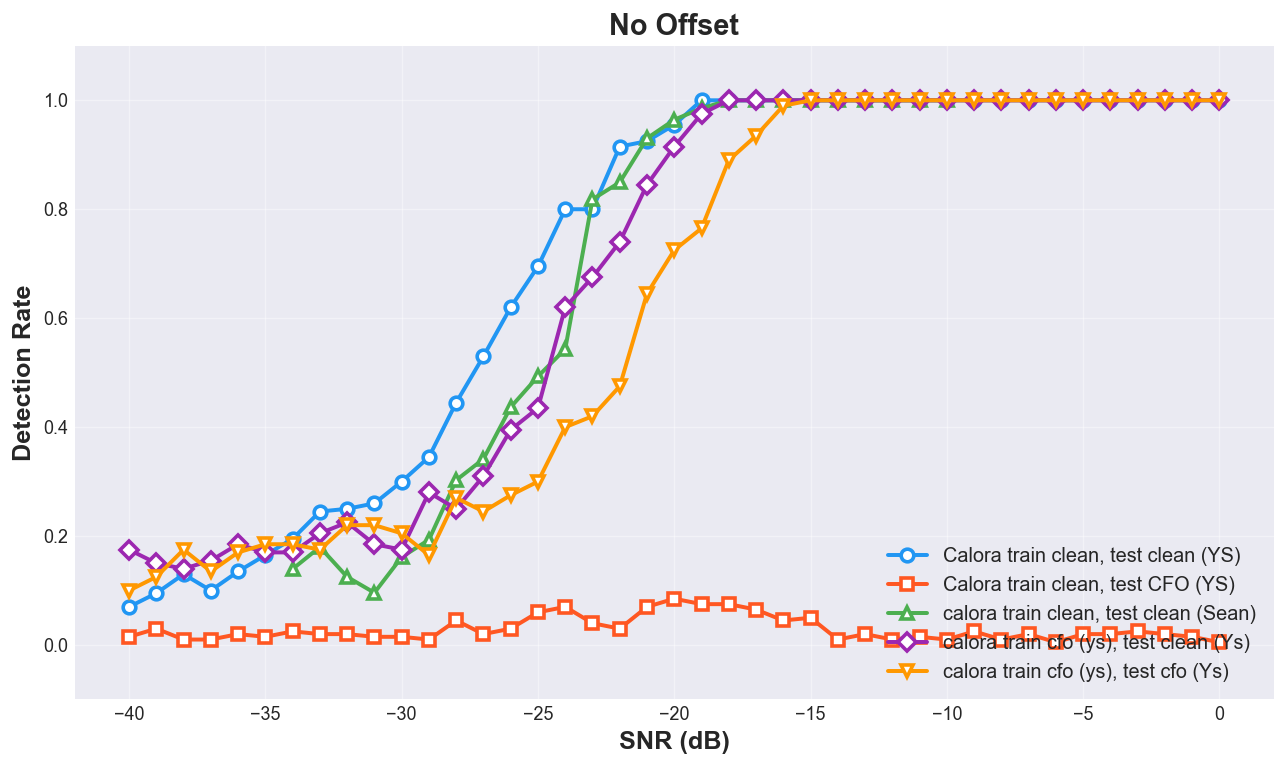


Plot saved to results/detrate_vs_snr_comparison.png


In [201]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).reset_index(drop=True)
    df = df.rename(columns={'snr': 'SNR', 'det_rate': 'DetRate'})
    if df['DetRate'].mean() > 1:
    # If yes, divide the entire column by 100 to convert it from percentages to decimals
        df['DetRate'] = df['DetRate'] / 100
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=colors[i % len(colors)],
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=colors[i % len(colors)],
        label=lbl
    )

ax.set_xlabel('SNR (dB)', fontsize=14, fontweight='bold')
ax.set_ylabel('Detection Rate', fontsize=14, fontweight='bold')
ax.set_title('No Offset', fontsize=16, fontweight='bold')
ax.set_ylim(-0.1, 1.10)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'detrate_vs_snr_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\nPlot saved to results/detrate_vs_snr_comparison.png')

In [202]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  EDIT HERE: specify the files you want to compare              ║
# ║  Use the exact filenames (without path) from the list above    ║
# ╚══════════════════════════════════════════════════════════════════╝

selected_files = [
    
    'calora_traincfo_testcfo.csv',
    'calora_traincfo_testcfosean.csv',
    'calora_results_20260807_175103.csv'
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    
     'calora train cfo (ys), test cfo (Ys)',
     'calora train cfo (ys), test cfo (Sean)',
     'calora train cfo (ys), test cfo (Sean) #2'
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ calora_traincfo_testcfo.csv
✅ calora_traincfo_testcfosean.csv
✅ calora_results_20260807_175103.csv


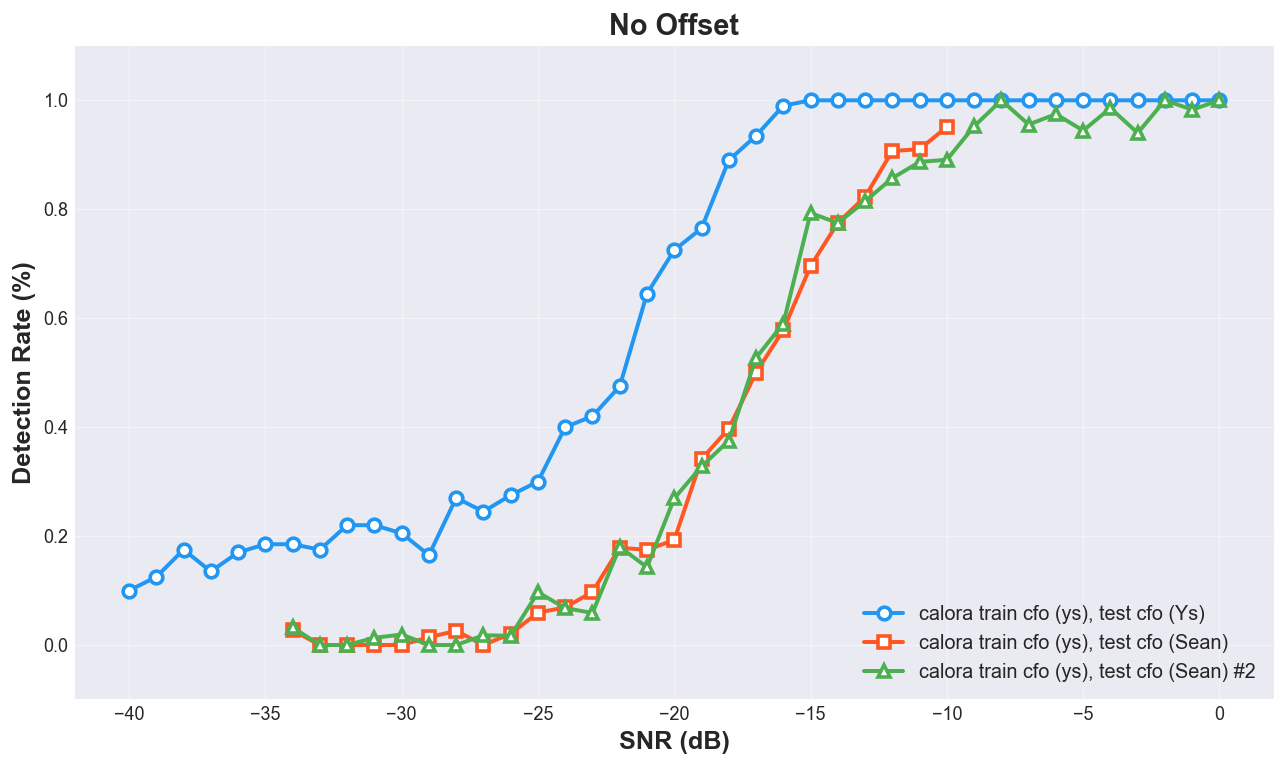


Plot saved to results/detrate_vs_snr_comparison.png


In [203]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#795548']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).reset_index(drop=True)
    df = df.rename(columns={'snr': 'SNR', 'det_rate': 'DetRate'})
    if df['DetRate'].mean() > 1:
    # If yes, divide the entire column by 100 to convert it from percentages to decimals
        df['DetRate'] = df['DetRate'] / 100
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=colors[i % len(colors)],
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=colors[i % len(colors)],
        label=lbl
    )

ax.set_xlabel('SNR (dB)', fontsize=14, fontweight='bold')
ax.set_ylabel('Detection Rate (%)', fontsize=14, fontweight='bold')
ax.set_title('No Offset', fontsize=16, fontweight='bold')
ax.set_ylim(-0.1, 1.10)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'detrate_vs_snr_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('\nPlot saved to results/detrate_vs_snr_comparison.png')